# Denoising Autoencoder for Image Restoration and Grayscale Image Colorization

## Abstract
This notebook is an educational research-style experiment on **denoising autoencoders**. A convolutional autoencoder is trained on CIFAR to10 to map *degraded* images (low-resolution + Gaussian noise + random masking) back to *clean* images. A second, lightweight experiment trains the same architecture with 1 input channel and 3 output channels to perform **grayscale image colorization** (grayscale to RGB prediction).

## Learning Objectives
1. Load and explore the CIFAR-10 dataset with `torchvision.datasets.CIFAR10` and `transforms.ToTensor()`.
2. Build an artificial degradation pipeline (low resolution, Gaussian noise, random masking, grayscale conversion) using pure tensor operations.
3. Implement and train a convolutional denoising autoencoder with `Conv2d` / `ConvTranspose2d`.
4. Visualize restoration results and grayscale colorization results.
5. Critically analyze why autoencoders restore images, and their limitations (blurriness, loss of fine details, color ambiguity).

> **Practical note:** full CIFAR-10 training is expensive on CPU, so we deliberately train on small **subsets** (configurable constants below). The first run downloads CIFAR-10 (~170 MB) and requires internet access; afterwards it is cached. Everything else runs top-to-bottom with no modification.


---

## 0. Setup: Imports, Seeds, Device and Configurable Constants

We import **only** PyTorch, torchvision, numpy and matplotlib. All hyperparameters are collected as clearly documented constants so the experiment is practical on CPU. `NUM_WORKERS=0` avoids multiprocessing issues (especially on Windows).


In [1]:
# ============================================================
# 0. Imports and global setup (only allowed third-party packages)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# ---- Reproducibility -------------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ---- Device (CPU / GPU) ----------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ---- Configurable constants ------------------------------------------------
DATA_ROOT = './data'          # where CIFAR-10 is downloaded/cached
BATCH_SIZE = 128              # mini-batch size for all DataLoaders
TRAIN_LIMIT = 10000           # training subset size (educational experiment)
VAL_LIMIT = 2000              # validation subset size
TEST_LIMIT = 2000             # test subset size
EPOCHS = 5                    # epochs for the denoising/restoration model
COLORIZATION_EPOCHS = 5       # epochs for the grayscale colorization model
NUM_WORKERS = 0               # 0 = main process only (Windows-safe, CPU-friendly)
LEARNING_RATE = 1e-3          # Adam learning rate

# CIFAR-10 class names (used for sample visualization)
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']


Using device: cuda


---

# Part 1 - Dataset Exploration

**CIFAR-10** consists of 60,000 tiny color images of size **32 x 32 pixels with 3 RGB channels** (50,000 train / 10,000 test) in **10 classes** (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

`transforms.ToTensor()` converts images to `float32` tensors in the range **[0, 1]** with shape `(3, 32, 32)`. We split the training set into train/val subsets with `torch.randperm`, capped by the configurable limits so we never exceed dataset sizes and never train on all 50,000 images.


In [2]:
# ============================================================
# 1. Download CIFAR-10 and build train / validation / test subsets
# ============================================================
# ToTensor() -> float tensor in [0,1], shape (3, 32, 32)
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=transform)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test  dataset size: {len(test_dataset)}')

# ---- Deterministic shuffled permutation of the training set ----------------
permutation = torch.randperm(len(train_dataset)).tolist()

# Limits never exceed the real dataset sizes
train_indices = permutation[:min(TRAIN_LIMIT, len(train_dataset))]
# validation indices come from the next unused slice of the permutation
val_start = len(train_indices)
val_indices = permutation[val_start: val_start + min(VAL_LIMIT, len(train_dataset) - val_start)]

# test indices from the (fixed) official test set
test_indices = list(range(min(TEST_LIMIT, len(test_dataset))))

train_subset = Subset(train_dataset, train_indices)
val_subset   = Subset(train_dataset, val_indices)
test_subset  = Subset(test_dataset,  test_indices)

# num_workers=0 avoids multiprocessing issues (e.g. on Windows)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train subset: {len(train_subset)} images | Val subset: {len(val_subset)} images | Test subset: {len(test_subset)} images')

# ---- Shape / range sanity checks on one batch ------------------------------
clean_batch, label_batch = next(iter(train_loader))
assert clean_batch.ndim == 4, 'expected a 4D batch (B, C, H, W)'
assert clean_batch.shape[1] == 3, 'CIFAR-10 must have 3 RGB channels'
assert clean_batch.shape[2] == 32 and clean_batch.shape[3] == 32, 'images must be 32x32'
assert clean_batch.min() >= 0.0 and clean_batch.max() <= 1.0, 'ToTensor output must be in [0, 1]'
print('Batch shape:', tuple(clean_batch.shape), '| value range: [%.3f, %.3f]' % (clean_batch.min(), clean_batch.max()))


100%|██████████| 170M/170M [20:47<00:00, 137kB/s]  


Train dataset size: 50000
Test  dataset size: 10000
Train subset: 10000 images | Val subset: 2000 images | Test subset: 2000 images
Batch shape: (128, 3, 32, 32) | value range: [0.000, 1.000]


### 1.1 Sample RGB images

Each image is converted from PyTorch's `(C, H, W)` layout to the numpy `(H, W, C)` layout expected by matplotlib (no PIL is used).


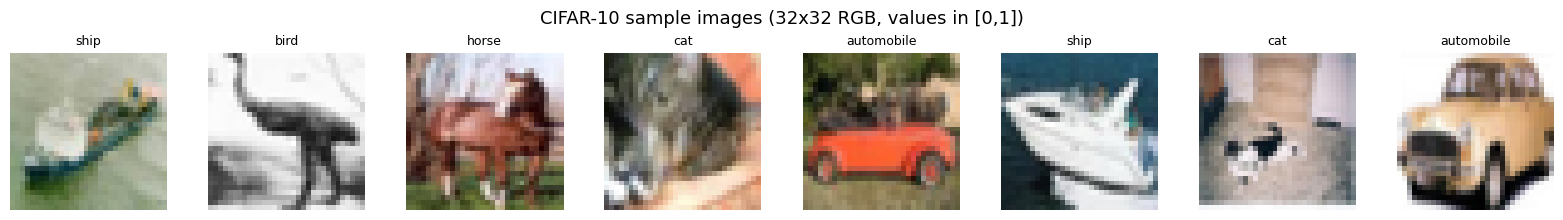

In [3]:
# ============================================================
# 1.1 Visualize sample RGB images with class names
# ============================================================
def show_image_grid(images, labels=None, title=None, n_cols=8):
    """Display a batch of (C,H,W) tensors in [0,1] as an image grid with matplotlib."""
    images = images.detach().cpu().numpy()
    n = images.shape[0]
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 2.2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            img = np.transpose(images[i], (1, 2, 0))  # CHW -> HWC for matplotlib
            ax.imshow(np.clip(img, 0.0, 1.0))
            if labels is not None:
                ax.set_title(CIFAR10_CLASSES[labels[i]], fontsize=9)
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# Take the first 8 images of the train batch for a quick look
n_show = 8
show_image_grid(clean_batch[:n_show], labels=label_batch[:n_show].tolist(),
                title='CIFAR-10 sample images (32x32 RGB, values in [0,1])', n_cols=n_show)


---

# Part 2 - Artificial Degradation Pipeline

We simulate common degradations directly on tensors, so the same functions are used for visualization **and** for training inputs:

| Function | Degradation | Description |
|---|---|---|
| `low_resolution_simulation` | Low resolution | downsample 32x32 -> 12x12, upsample back (bilinear, `align_corners=False`) |
| `add_gaussian_noise` | Sensor noise | add `N(0, sigma^2)` noise, clamp to [0, 1] |
| `add_random_mask` | Masking noise | element-wise zero mask: keep pixel where `rand > p`, shape preserved |
| `rgb_to_grayscale` | Color removal | luminance weights `[0.299, 0.587, 0.114]` |

`create_degraded_images` applies **low resolution -> Gaussian noise -> random masking** in sequence and clamps the result to [0, 1]. This combined degradation is the input the restoration autoencoder will learn to invert.


In [4]:
# ============================================================
# 2. Degradation functions (pure torch tensors, differentiable)
# ============================================================
def low_resolution_simulation(images, low_size=12):
    """Simulate low resolution: 32x32 -> low_size x low_size -> 32x32 (bilinear)."""
    B, C, H, W = images.shape
    small = F.interpolate(images, size=(low_size, low_size), mode='bilinear', align_corners=False)
    upsampled = F.interpolate(small, size=(H, W), mode='bilinear', align_corners=False)
    return torch.clamp(upsampled, 0.0, 1.0)

def add_gaussian_noise(images, sigma=0.12):
    """Add Gaussian noise N(0, sigma^2) and clamp to [0,1]."""
    noise = torch.randn_like(images) * sigma
    return torch.clamp(images + noise, 0.0, 1.0)

def add_random_mask(images, mask_probability=0.15):
    """Element-wise random masking noise: keep pixel where rand > p, else set to 0.
    The mask has the same shape as the input, so the output shape is preserved."""
    mask = (torch.rand_like(images) > mask_probability).to(images.dtype)
    return images * mask

def rgb_to_grayscale(images):
    """Convert (B,3,H,W) RGB images in [0,1] to (B,1,H,W) grayscale (ITU-R 601 weights).
    The weights tensor is created on the same device/dtype as the input."""
    weights = torch.tensor([0.299, 0.587, 0.114],
                           device=images.device, dtype=images.dtype).reshape(1, 3, 1, 1)
    gray = (images * weights).sum(dim=1, keepdim=True)  # weighted sum over channels
    return gray

def create_degraded_images(images):
    """Full degradation pipeline: low resolution -> Gaussian noise -> random masking."""
    degraded = low_resolution_simulation(images, low_size=12)
    degraded = add_gaussian_noise(degraded, sigma=0.12)
    degraded = add_random_mask(degraded, mask_probability=0.15)
    return torch.clamp(degraded, 0.0, 1.0)

# sanity checks: shapes and value range are preserved
_deg_check = create_degraded_images(clean_batch)
assert _deg_check.shape == clean_batch.shape, 'degradation must preserve shape'
assert _deg_check.min() >= 0.0 and _deg_check.max() <= 1.0, 'degraded images must stay in [0,1]'
print('Degraded batch shape:', tuple(_deg_check.shape))


Degraded batch shape: (128, 3, 32, 32)


### 2.1 Original -> Degraded comparison

We take a deterministic batch from the test loader and show a 4-row comparison: **original clean**, **low-resolution simulation**, **combined degraded** (low-res + noise + mask), and **grayscale**. This is the classic *Original image -> Degraded image* side-by-side view.


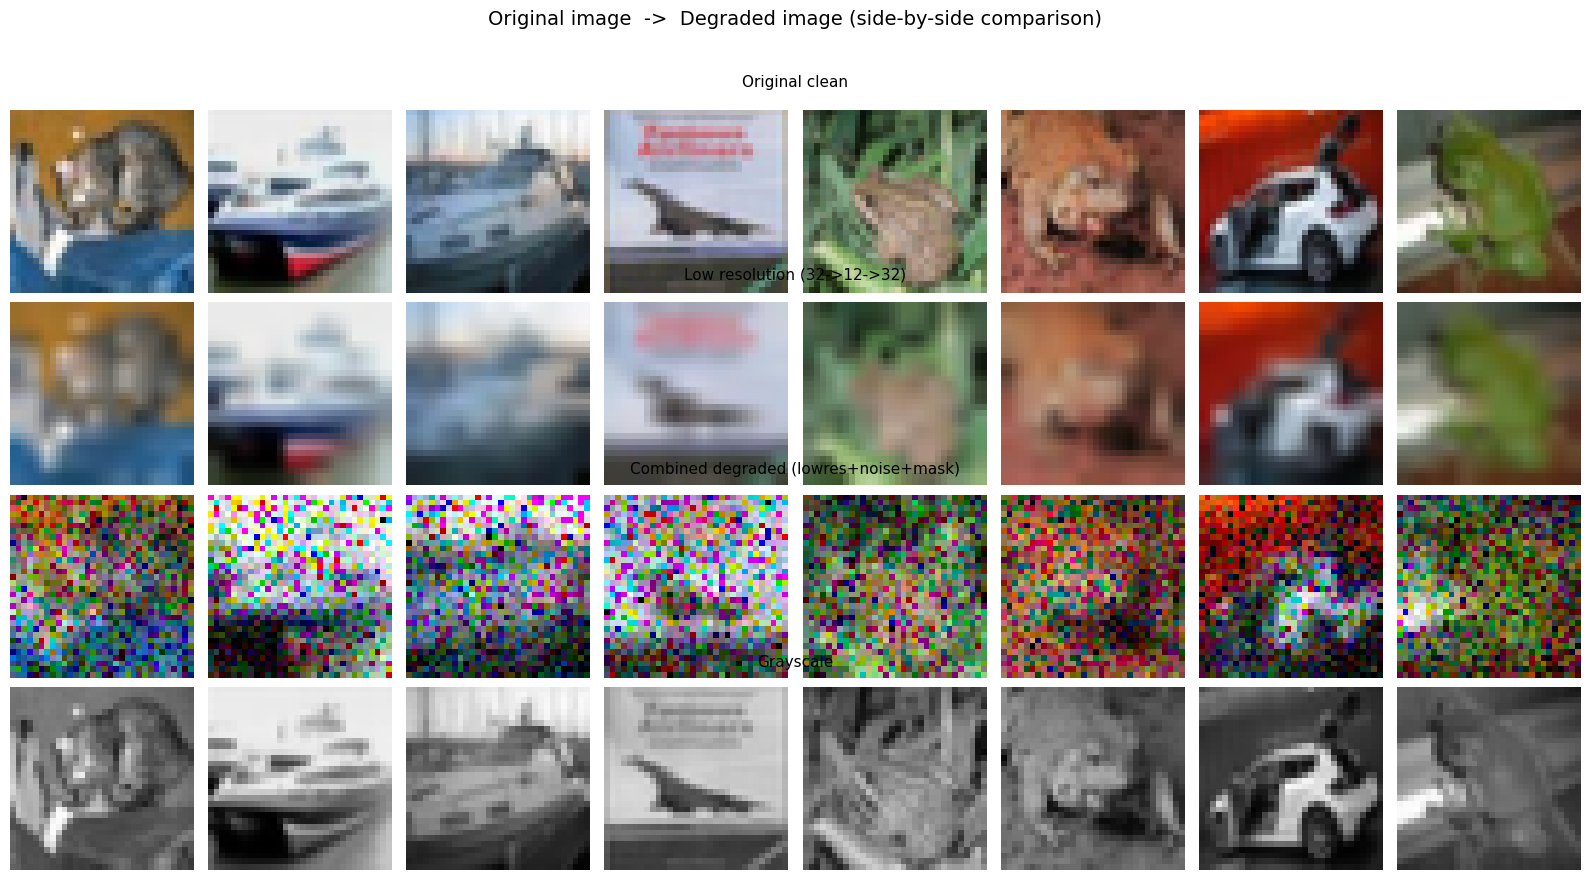

In [5]:
# ============================================================
# 2.1 Visualize degradation examples (Original vs Degraded, side by side)
# ============================================================
# deterministic first test batch
test_batch, test_labels = next(iter(test_loader))

with torch.no_grad():
    low_res_example   = low_resolution_simulation(test_batch)
    degraded_example  = create_degraded_images(test_batch)
    grayscale_example = rgb_to_grayscale(test_batch)

n_show = 8
row_titles = ['Original clean', 'Low resolution (32->12->32)',
              'Combined degraded (lowres+noise+mask)', 'Grayscale']
rows = [test_batch[:n_show], low_res_example[:n_show],
        degraded_example[:n_show], grayscale_example[:n_show].repeat(1, 3, 1, 1)]

fig, axes = plt.subplots(4, n_show, figsize=(2.0 * n_show, 9.0))
for row, (row_images, row_title) in enumerate(zip(rows, row_titles)):
    for col in range(n_show):
        ax = axes[row, col]
        img = row_images[col].detach().cpu().numpy()
        img = np.transpose(img, (1, 2, 0))          # CHW -> HWC
        if img.shape[2] == 1:                       # single-channel -> repeat for display
            img = np.repeat(img, 3, axis=2)
        ax.imshow(np.clip(img, 0.0, 1.0))
        ax.axis('off')
        ax.axis('off')
    fig.text(0.5, 0.895 - 0.215 * row, row_title, ha='center', fontsize=11)
plt.suptitle('Original image  ->  Degraded image (side-by-side comparison)', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


---

# Part 3 - Denoising Autoencoder

### 3.1 Architecture

A fully convolutional autoencoder with a 3-level encoder/decoder pair:

- **Encoder:** `Conv2d` 3->32, 32->64, 64->128 (kernel 3, padding 1), each followed by `ReLU` and `MaxPool2d(2)`; the latent feature map is `128 x 4 x 4`.
- **Decoder:** `ConvTranspose2d` 128->64, 64->32, 32->output (kernel 2, stride 2) with `ReLU` between layers and `Sigmoid` at the output so predictions live in [0, 1].

The same class is reused for colorization with `input_channels=1, output_channels=3`.


In [6]:
# ============================================================
# 3.1 Convolutional Autoencoder model
# ============================================================
class ConvolutionalAutoencoder(nn.Module):
    """Symmetric convolutional autoencoder for 32x32 RGB images.
    Encoder: Conv2d(3->32)-ReLU-MaxPool | Conv2d(32->64)-ReLU-MaxPool | Conv2d(64->128)-ReLU-MaxPool
    Latent:  128 x 4 x 4 feature map
    Decoder: ConvTranspose2d(128->64)-ReLU | ConvTranspose2d(64->32)-ReLU | ConvTranspose2d(32->out)-Sigmoid
    """
    def __init__(self, input_channels=3, output_channels=3):
        super().__init__()
        # ---- Encoder ----
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),             # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),             # 8x8 -> 4x4
        )
        # ---- Decoder ----
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),                      # 4x4 -> 8x8
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  nn.ReLU(),                      # 8x8 -> 16x16
            nn.ConvTranspose2d(32, output_channels, kernel_size=2, stride=2),                     # 16x16 -> 32x32
            nn.Sigmoid(),   # output in [0,1], matches the ToTensor range
        )

    def forward(self, x):
        latent = self.encoder(x)             # compressed latent representation
        reconstruction = self.decoder(latent)
        return reconstruction

# ---- Instantiate the restoration model --------------------------------------
restoration_model = ConvolutionalAutoencoder(input_channels=3, output_channels=3).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(restoration_model.parameters(), lr=LEARNING_RATE)

n_params = sum(p.numel() for p in restoration_model.parameters())
print(f'Restoration model parameters: {n_params:,}')
print(restoration_model)


Restoration model parameters: 134,691
ConvolutionalAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)


### 3.2 Training / evaluation loop functions

`make_input` is a callable (e.g. `create_degraded_images`) that produces the model input from the **clean** images; the clean images themselves are always the targets - labels are never used. Losses are averaged weighted by batch size.


In [7]:
# ============================================================
# 3.2 Generic train / evaluate functions
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, make_input, device):
    """One training epoch: input = make_input(clean_images), target = clean_images."""
    model.train()
    total_loss, total_samples = 0.0, 0
    for clean_images, _ in loader:            # labels are ignored on purpose
        clean_images = clean_images.to(device)
        inputs = make_input(clean_images)     # e.g. create_degraded_images / grayscale_input
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, clean_images)
        loss.backward()
        optimizer.step()
        batch_size = clean_images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
    return total_loss / max(total_samples, 1)

def evaluate(model, loader, criterion, make_input, device):
    """Evaluate average MSE over a loader (no gradients, model.eval)."""
    model.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for clean_images, _ in loader:
            clean_images = clean_images.to(device)
            inputs = make_input(clean_images)
            outputs = model(inputs)
            loss = criterion(outputs, clean_images)
            batch_size = clean_images.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
    return total_loss / max(total_samples, 1)


### 3.3 Train the denoising autoencoder

Each epoch prints the training and validation MSE. The loss curves are plotted at the end.


Epoch 01/5 | train MSE: 0.04117 | val MSE: 0.02317
Epoch 02/5 | train MSE: 0.02099 | val MSE: 0.01865
Epoch 03/5 | train MSE: 0.01754 | val MSE: 0.01548
Epoch 04/5 | train MSE: 0.01486 | val MSE: 0.01414
Epoch 05/5 | train MSE: 0.01379 | val MSE: 0.01346


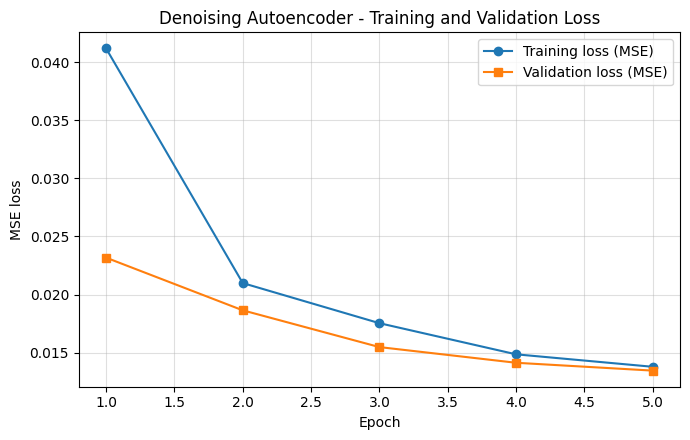

In [8]:
# ============================================================
# 3.3 Train the restoration (denoising) autoencoder
# ============================================================
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(restoration_model, train_loader, optimizer, criterion,
                                 make_input=create_degraded_images, device=device)
    val_loss = evaluate(restoration_model, val_loader, criterion,
                        make_input=create_degraded_images, device=device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch {epoch:02d}/{EPOCHS} | train MSE: {train_loss:.5f} | val MSE: {val_loss:.5f}')

# ---- Loss curves -----------------------------------------------------------
epochs_axis = range(1, EPOCHS + 1)
plt.figure(figsize=(7, 4.5))
plt.plot(epochs_axis, train_losses, 'o-', label='Training loss (MSE)')
plt.plot(epochs_axis, val_losses, 's-', label='Validation loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Denoising Autoencoder - Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


---

# Part 4 - Image Restoration Visualization

We show, for several test images, the columns **Original clean -> Corrupted input -> Autoencoder reconstruction**.

**How the mapping works:** the corrupted image is pushed through the encoder into a small latent feature map (`128 x 4 x 4`). Because the model was trained to reconstruct *clean* images *from corrupted* inputs, the latent code encodes the likely underlying clean content (edges, object shape, color statistics) rather than the exact noise pattern. The decoder then decodes this latent representation back into a clean-looking 32x32 RGB image - i.e. it learns the conditional mapping **corrupted image -> latent representation -> clean image**.


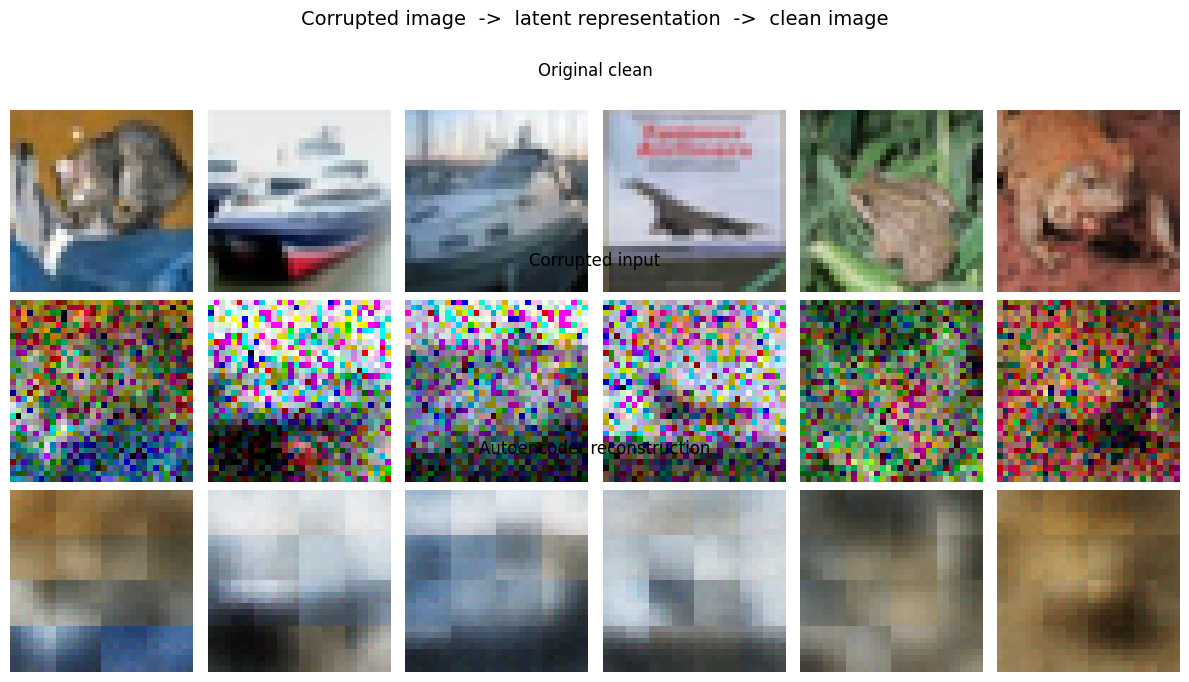

In [9]:
# ============================================================
# 4. Restoration results on test images
# ============================================================
restoration_model.eval()
with torch.no_grad():
    corrupted_batch = create_degraded_images(test_batch.to(device))
    restored_batch = restoration_model(corrupted_batch)

n_show = 6
row_titles = ['Original clean', 'Corrupted input', 'Autoencoder reconstruction']
rows = [test_batch[:n_show], corrupted_batch[:n_show].cpu(), restored_batch[:n_show].cpu()]

fig, axes = plt.subplots(3, n_show, figsize=(2.0 * n_show, 7.0))
for row, (row_images, row_title) in enumerate(zip(rows, row_titles)):
    for col in range(n_show):
        ax = axes[row, col]
        img = row_images[col].detach().cpu().numpy()
        img = np.clip(np.transpose(img, (1, 2, 0)), 0.0, 1.0)  # CHW -> HWC, [0,1]
        ax.imshow(img)
        ax.axis('off')
    fig.text(0.5, 0.885 - 0.27 * row, row_title, ha='center', fontsize=12)
plt.suptitle('Corrupted image  ->  latent representation  ->  clean image', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


---

# Part 5 - Lightweight Grayscale Image Colorization Experiment

We reuse the same architecture with **1 input channel** (grayscale) and **3 output channels** (RGB). The encoder now starts with `Conv2d(1->32)` while keeping the rest identical (32->64->128 latent, decoder back to 3 channels with `Sigmoid`).

Training maps `grayscale image -> predicted RGB image`, with the original RGB image as target. This is a highly ambiguous task (many plausible colors per gray pixel), so we expect plausible but not exact colors - see Part 6.


In [10]:
# ============================================================
# 5.1 Colorization model and grayscale input function
# ============================================================
def grayscale_input(images):
    """Model input transform for colorization: RGB -> grayscale (1 channel)."""
    return rgb_to_grayscale(images)

# same architecture, 1 input channel / 3 output channels
colorization_model = ConvolutionalAutoencoder(input_channels=1, output_channels=3).to(device)
colorization_criterion = nn.MSELoss()
colorization_optimizer = optim.Adam(colorization_model.parameters(), lr=LEARNING_RATE)

print(f'Colorization model parameters: {sum(p.numel() for p in colorization_model.parameters()):,}')
# quick shape check of the grayscale path
_gray_check = grayscale_input(clean_batch)
assert _gray_check.shape == (clean_batch.size(0), 1, 32, 32), 'grayscale input must be (B,1,32,32)'
print('Grayscale input shape:', tuple(_gray_check.shape))


Colorization model parameters: 134,115
Grayscale input shape: (128, 1, 32, 32)


Epoch 01/5 | train MSE: 0.04129 | val MSE: 0.02230
Epoch 02/5 | train MSE: 0.02026 | val MSE: 0.01854
Epoch 03/5 | train MSE: 0.01781 | val MSE: 0.01697
Epoch 04/5 | train MSE: 0.01658 | val MSE: 0.01599
Epoch 05/5 | train MSE: 0.01562 | val MSE: 0.01504


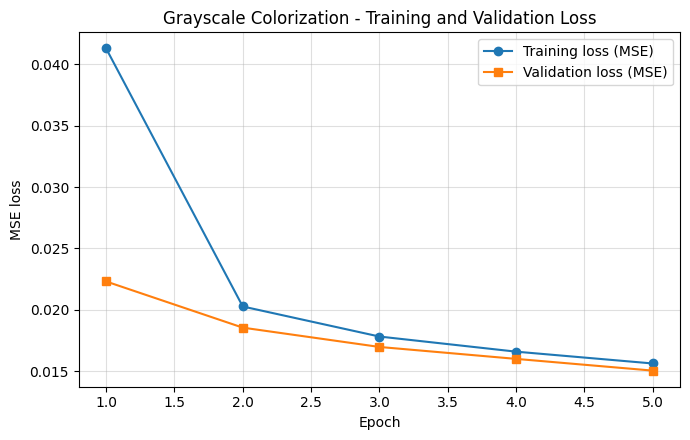

In [11]:
# ============================================================
# 5.2 Train the colorization model
# ============================================================
colorization_train_losses, colorization_val_losses = [], []

for epoch in range(1, COLORIZATION_EPOCHS + 1):
    train_loss = train_one_epoch(colorization_model, train_loader, colorization_optimizer,
                                 colorization_criterion, make_input=grayscale_input, device=device)
    val_loss = evaluate(colorization_model, val_loader, colorization_criterion,
                        make_input=grayscale_input, device=device)
    colorization_train_losses.append(train_loss)
    colorization_val_losses.append(val_loss)
    print(f'Epoch {epoch:02d}/{COLORIZATION_EPOCHS} | train MSE: {train_loss:.5f} | val MSE: {val_loss:.5f}')

# ---- Loss curves -----------------------------------------------------------
epochs_axis = range(1, COLORIZATION_EPOCHS + 1)
plt.figure(figsize=(7, 4.5))
plt.plot(epochs_axis, colorization_train_losses, 'o-', label='Training loss (MSE)')
plt.plot(epochs_axis, colorization_val_losses, 's-', label='Validation loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Grayscale Colorization - Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### 5.3 Colorization results

For several test images we show **grayscale input -> predicted colorization -> original RGB target**. Because the loss is pixel-wise MSE, the model typically predicts average-ish but plausible colors (e.g. bluish skies, greenish landscapes) rather than the exact original colors.


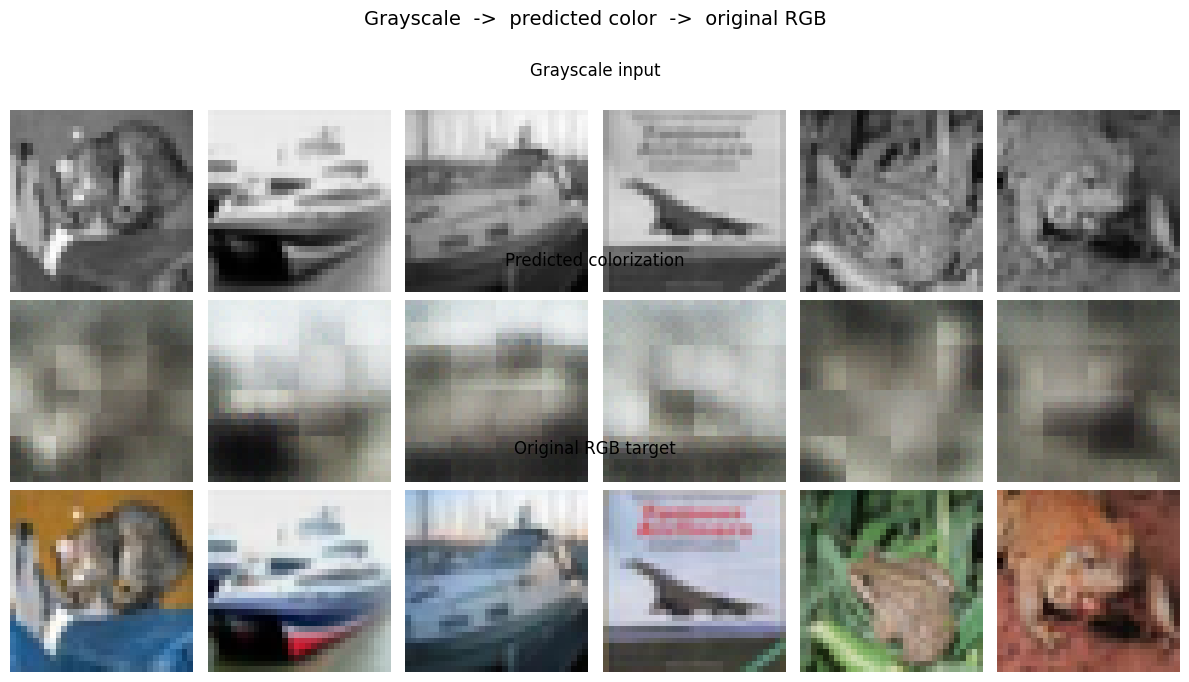

In [12]:
# ============================================================
# 5.3 Visualize grayscale input, colorization output and RGB target
# ============================================================
colorization_model.eval()
with torch.no_grad():
    gray_batch = grayscale_input(test_batch.to(device))
    colorized_batch = colorization_model(gray_batch)

n_show = 6
row_titles = ['Grayscale input', 'Predicted colorization', 'Original RGB target']
rows = [gray_batch[:n_show].repeat(1, 3, 1, 1).cpu(),  # repeat gray channel for display
        colorized_batch[:n_show].cpu(),
        test_batch[:n_show]]

fig, axes = plt.subplots(3, n_show, figsize=(2.0 * n_show, 7.0))
for row, (row_images, row_title) in enumerate(zip(rows, row_titles)):
    for col in range(n_show):
        ax = axes[row, col]
        img = row_images[col].detach().cpu().numpy()
        img = np.clip(np.transpose(img, (1, 2, 0)), 0.0, 1.0)  # CHW -> HWC, [0,1]
        ax.imshow(img)
        ax.axis('off')
    fig.text(0.5, 0.885 - 0.27 * row, row_title, ha='center', fontsize=12)
plt.suptitle('Grayscale  ->  predicted color  ->  original RGB', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


---

# Part 6 - Research Analysis

## 6.1 Why autoencoders can restore images

An autoencoder compresses an image through a low-dimensional **bottleneck** and reconstructs it back. When trained on *degraded inputs with clean targets*, it learns the conditional mapping `p(clean | degraded)`. The bottleneck acts as an information filter: noise and compression artifacts are high-entropy, hard-to-compress structure, while the clean image content (edges, object shapes, textures, global color layout) is structured and compressible. The network therefore tends to keep the useful image prior and discard the corruption. **Convolutional locality and shared weights** add a strong natural-image prior: nearby pixels are correlated, and the same filters apply everywhere, so the model learns local denoising / detail-synthesis operators that generalize across positions.

## 6.2 Normal vs Denoising vs Super-resolution Autoencoder

| Variant | Input | Target | What it learns |
|---|---|---|---|
| **Normal autoencoder** | clean image `x` | `x` itself | identity-like compression; learns a latent code, but no corruption removal |
| **Denoising autoencoder** | corrupted image `x + noise` | clean `x` | inverse of the corruption process; robust latent features, denoising prior |
| **Super-resolution autoencoder** | low-resolution imageising prior |
| **Super-resolution autoencoder** | low-resolution image plausible high-frequency detail |

Our restoration model combines all three effects: its inputs are simultaneously low-resolution, noisy and masked, so it learns a joint restoration mapping.

## 6.3 What the latent space captures

The `128 x 4 x 4` bottleneck cannot store every pixel value, so it must encode abstract, reusable visual features: **object edges and contours, texture statistics, global shape/layout, and color / semantic structure** (e.g. 'sky above, ground below' for outdoor classes). For the colorization model the latent code additionally captures which semantic region a pixel belongs to, since plausible colors depend on object identity (sky -> blue, grass -> green).

## 6.4 Limitations

- **Blurry outputs:** pixel-wise MSE is minimized by predicting the *conditional mean*, which averages over all plausible clean images -> blurry reconstructions. (Adversarial or perceptual losses mitigate this.)
- **Loss of fine details:** a small latent bottleneck plus few training epochs discards small textures and thin structures.
- **Plausible-but-not-exact colors in colorization:** colorization is ill-posed (a gray cat could be many colors); MSE encourages dull, averaged colors.
- **Dependence on the corruption distribution:** the model only inverts degradations similar to those it was trained on (here: 12x12 low-res, sigma=0.12 noise, 15% masking).
- **Scale of the experiment:** only 10,000 train images and 5 epochs - a deliberately small, CPU-friendly educational setup.
- **No semantic guarantee:** a low-MSE reconstruction is not necessarily semantically correct; visually good results can still misrepresent fine content.

## 6.5 Checklist - what to inspect in curves and images

- [ ] Loss curves decrease and **validation loss tracks training loss** (no large gap -> no severe overfitting).
- [ ] Restoration outputs remove noise/mask artifacts and recover global structure, but remain **slightly blurry**.
- [ ] The corrupted -> reconstruction comparison shows cleaner colors and structure than the corrupted inputs.
- [ ] Colorization outputs show plausible **region-consistent colors**, not the exact originals.
- [ ] Re-running with more epochs / data (raise `EPOCHS`, `TRAIN_LIMIT`) should visibly improve quality.

### Experiment summary

| Component | Setting |
|---|---|
| Dataset | CIFAR-10, 32x32 RGB, 10 classes (train/val/test subsets: 10000/2000/2000) |
| Degradations | bilinear 12x12 low-res, Gaussian noise sigma=0.12, 15% random masking |
| Architecture | Conv AE: 3->32->64->128 encoder (MaxPool), 128->64->32->3 decoder (ConvTranspose + Sigmoid) |
| Loss / Optimizer | MSELoss / Adam (lr=1e-3) |
| Restoration | input = degraded image, target = clean image, 5 epochs |
| Colorization | input = grayscale (1 ch), output = RGB (3 ch), 5 epochs |
